In [1]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings

embedding_function = OpenAIEmbeddings(model="text-embedding-3-large")

vectorstore = Chroma(       
    embedding_function=embedding_function,
    collection_name="income_tax_collection",
    persist_directory="./income_tax_collection"
)

retriever = vectorstore.as_retriever(search_kwargs={"k": 3})


In [2]:
from typing_extensions import List,TypedDict
from langchain_core.documents import Document
from langgraph.graph import StateGraph


class AgentState(TypedDict):
    query: str
    answer: str
    context: List[Document]
    
    
graph_builder = StateGraph(AgentState)
    

In [3]:
def retrieve(state: AgentState) :
    query = state["query"]
    docs = retriever.invoke(query)
    return {"context": docs}

In [4]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o")

In [5]:
from langsmith import Client

client = Client()
generate_prompt = client.pull_prompt("rlm/rag-prompt")
generate_llm = ChatOpenAI(model="gpt-4o", max_completion_tokens=100)

def generate(state:AgentState) :
    context = state["context"]
    query = state["query"]
    rag_chain = generate_prompt | generate_llm
    response = rag_chain.invoke({"context": context, "question": query})
    return {"answer": response}


In [6]:
# 문서 관련성 측정 노드 (상태에 _next를 넣어 다음 노드로 연결)

from langsmith import Client
from typing import Literal

client = Client()
doc_relevance_prompt = client.pull_prompt("langchain-ai/rag-document-relevance")

def check_doc_relevance(state: AgentState) -> Literal["relevant", "irrelevant"]:
    query = state["query"]
    context = state["context"]
    doc_relevance_chain = doc_relevance_prompt | llm
    response = doc_relevance_chain.invoke({"documents": context, "question": query})
    # 응답에서 Score 추출 (AIMessage면 .content, dict면 ["Score"])
    if response['Score'] == 1:
        return 'relevant'
    else:
        return 'irrelevant'


In [7]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

dictionary = ['사람과 관련된 표현 -> 거주자']

rewrite_prompt = PromptTemplate.from_template(
    f"""
    주어진 질문에 대한 답변을 찾아보고, 우리의 사전을 참고해서 사용자의 질문을 변경해주세요.
    사전 : {dictionary}
    질문 : {{query}}
    """
)

def rewrite(state:AgentState) :
    query = state["query"]
    rewrite_chain = rewrite_prompt | llm | StrOutputParser()
    
    response = rewrite_chain.invoke({"query": query})
    return {"query": response}

In [8]:
#from langsmith import Client
#
#client = Client()
#hallucination_prompt = client.pull_prompt("langchain-ai/rag-answer-hallucination")

from langchain_core.prompts import PromptTemplate

hallucination_prompt = PromptTemplate.from_template(
    """
        You are a teacher tasked with evaluating whether a student's answer is based on documents or not,
        Given documents, which are excerpts from income tax law, and a student's answer;
        If the student's answer is based on documents, respond with "not hallucinated",
        If the student's answer is not based on documents, respond with "hallucinated".

        documents: {documents}
        student_answer: {student_answer}
    """
)

hallucination_llm = ChatOpenAI(model='gpt-4o', temperature=0)

def check_hallucination(state:AgentState) -> Literal["hallucinated", "not hallucinated"]:
    context = state["context"]
    answer = state["answer"]
    context = [doc.page_content for doc in context]
    hallucination_chain = hallucination_prompt | hallucination_llm | StrOutputParser()
    response = hallucination_chain.invoke({"student_answer": answer, "documents": context})
    return response



In [9]:
query = '얀봉 5천만원의 거주자의 소득세는 얼마인가요?'
context = retriever.invoke(query)
generate_state = {"context": context, "query": query}
answer = generate(generate_state)
hallucination_state = {"context": context, "answer": answer}

check_hallucination(hallucination_state)

'not hallucinated'

In [10]:
from langsmith import Client

client = Client()
helpfulness_prompt = client.pull_prompt("langchain-ai/rag-answer-helpfulness")

def check_helpfulness_grader(state:AgentState):
    query = state["query"]
    answer = state["answer"]
    helpfulness_chain = helpfulness_prompt | llm 
    response = helpfulness_chain.invoke({"question": query, "student_answer": answer})
    if response == "helpful":
        return "helpful"
    
    return "not helpful"

def check_helpfulness(state:AgentState):
    return state

In [11]:
query = '얀봉 5천만원의 거주자의 소득세는 얼마인가요?'
context = retriever.invoke(query)
generate_state = {"context": context, "query": query}
answer = generate(generate_state)
helpfulness_state = {"query": query, "answer": answer}

check_helpfulness(helpfulness_state)

{'query': '얀봉 5천만원의 거주자의 소득세는 얼마인가요?',
 'answer': {'answer': AIMessage(content='얀봉 5천만원의 거주자의 소득세는 624만원입니다. 5천만원은 8,800만원 이하 구간에 해당하며, 이 구간의 세율에 따라 5,000만원을 초과하는 금액의 24%를 추가하여 계산합니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 66, 'prompt_tokens': 1796, 'total_tokens': 1862, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1792}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_eadf229d54', 'id': 'chatcmpl-D3HUNr7qIaiT99473WuVEXeoJJrE2', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019c08d3-2e94-7113-a563-6b0f0faabece-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1796, 'output_tokens': 66, 'total_tokens': 1862, 'input_token_details': {'audio': 0, 'cache_read': 1792}, 'output_token

In [12]:
graph_builder.add_node('retrieve', retrieve)
graph_builder.add_node('generate', generate)
graph_builder.add_node('rewrite', rewrite)
graph_builder.add_node('check_helpfulness', check_helpfulness)


In [13]:

from langgraph.graph import START, END

graph_builder.add_edge(START, 'retrieve')
graph_builder.add_conditional_edges(
    'retrieve',
    check_doc_relevance,
    {
        'relevant': 'generate',
        'irrelevant': END
    }
)
graph_builder.add_conditional_edges(
    'generate',
    check_hallucination,
    {
        'hallucinated': 'generate',
        'not hallucinated': 'check_helpfulness'
    }
)
graph_builder.add_conditional_edges(
    'check_helpfulness',
    check_helpfulness_grader,
    {
        'helpful': END,
        'not helpful': 'rewrite'
    }
)
graph_builder.add_edge('rewrite', 'retrieve')

In [14]:
graph = graph_builder.compile()

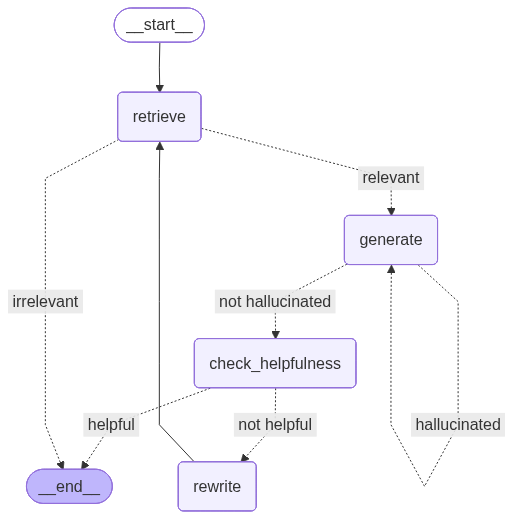

In [15]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [16]:
initial_state = {"query": query}
graph.invoke(initial_state)

{'query': '질문: 연봉 5천만 원인 거주자의 소득세는 얼마인가요?',
 'answer': AIMessage(content='얀봉 5천만원의 거주자 소득세는 624만원입니다. 이는 1,400만원 초과부터 8,800만원 이하 구간에 해당하여, 5,000만원을 초과하는 금액에 대해 24% 세율이 적용되기 때문입니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 66, 'prompt_tokens': 1796, 'total_tokens': 1862, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1792}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_eadf229d54', 'id': 'chatcmpl-D3HUYQgmCdbMHoBTqLvzYndi8L1FZ', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019c08d3-5972-7083-834d-88d4719a9758-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1796, 'output_tokens': 66, 'total_tokens': 1862, 'input_token_details': {'audio': 0, 'cache_read': 1792}, 'output_token_det